#Business Case

Customer yang datang ke toko memiliki karakteristik terntentu saat berbelanja yang bisa diamati sehingga membantu store untuk mengevaluasi performa penjualan juga menyusun langkah strategis agar store semakin meningkat performanya. Untuk itu dibutuhkan analisa data yang berkaitan dengan permasalahan ini. Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. Sehingga pada analisis kali ini ingin diketahui bagaimana karakteristik masing-masing customer melalui visualisasi data dan metode anailisa "Classification Customer yang bukan anggota dan anggota / lalu Clustering yang bukan anggota?"

## Data Understanding

In [269]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [270]:
df = pd.read_csv("/content/train_features.csv")
df.head(10)

,tahun_kelahiran,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,terakhir_belanja,belanja_buah,belanja_daging,belanja_ikan,belanja_kue,pembelian_diskon,pembelian_web,pembelian_toko,keluhan,tanggal_menjadi_anggota,jumlah_promosi
0,1979,Sarjana,Rencana Menikah,NaN,0.0,1.0,NaN,50575.0,260967.0,50575.0,20230.0,2.0,2.0,5.0,0.0,5/5/2014,2
1,1950,Sarjana,Rencana Menikah,84063000.0,NaN,NaN,70.0,6069.0,44506.0,80920.0,20230.0,9.0,6.0,4.0,0.0,3/17/2013,0
2,1966,Sarjana,Menikah,127532564.0,0.0,0.0,45.0,117611.0,265460.0,96341.0,145573.0,1.0,1.0,7.0,0.0,NaN,1
3,1961,Magister,Rencana Menikah,165579620.0,0.0,0.0,90.0,206346.0,1613901.0,27725.0,125868.0,0.0,7.0,8.0,0.0,NaN,4
4,1970,Sarjana,Rencana Menikah,117703159.0,1.0,1.0,78.0,90563.0,311757.0,40358.0,33875.0,7.0,6.0,5.0,0.0,NaN,4
5,1952,Magister,Sendiri,94346105.0,0.0,0.0,9.0,33509.0,49228.0,0.0,NaN,1.0,4.0,2.0,0.0,NaN,5
6,1963,Magister,Sendiri,75313000.0,2.0,NaN,96.0,0.0,14161.0,8092.0,2023.0,1.0,4.0,5.0,0.0,5/3/2013,0
7,1959,Sarjana,Rencana Menikah,137916316.0,0.0,0.0,21.0,38505.0,1146659.0,192956.0,240718.0,4.0,NaN,6.0,0.0,NaN,5
8,1957,Sarjana,Sendiri,138069883.0,0.0,0.0,26.0,56486.0,NaN,193754.0,202737.0,3.0,9.0,5.0,0.0,NaN,5
9,1975,Sarjana,Menikah,37567504.0,1.0,NaN,67.0,19061.0,28067.0,22223.0,14146.0,3.0,2.0,1.0,0.0,NaN,2


In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3817 entries, 0 to 3816
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tahun_kelahiran          3817 non-null   int64  
 1   pendidikan               3628 non-null   object 
 2   status_pernikahan        3605 non-null   object 
 3   pendapatan               3627 non-null   float64
 4   jumlah_anak_balita       3627 non-null   float64
 5   jumlah_anak_remaja       3613 non-null   float64
 6   terakhir_belanja         3645 non-null   float64
 7   belanja_buah             3636 non-null   float64
 8   belanja_daging           3639 non-null   float64
 9   belanja_ikan             3624 non-null   float64
 10  belanja_kue              3603 non-null   float64
 11  pembelian_diskon         3639 non-null   float64
 12  pembelian_web            3652 non-null   float64
 13  pembelian_toko           3648 non-null   float64
 14  keluhan                 

In [272]:
df.describe()

,tahun_kelahiran,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,terakhir_belanja,belanja_buah,belanja_daging,belanja_ikan,belanja_kue,pembelian_diskon,pembelian_web,pembelian_toko,keluhan,jumlah_promosi
count,3817.000000,3.627000e+03,3627.000000,3613.000000,3645.000000,3636.000000,3.639000e+03,3624.000000,3603.000000,3639.000000,3652.000000,3648.000000,3621.000000,3817.000000
mean,1967.823946,1.144832e+08,0.293080,0.353723,47.231550,59804.239824,4.385748e+05,81428.997792,63377.970580,2.125584,4.436473,5.767818,0.004971,2.585800
std,11.768131,4.346042e+07,0.473063,0.493014,27.068512,74024.976109,5.120427e+05,99976.226855,79435.457282,2.100133,3.002522,3.210738,0.070340,2.101845
min,1899.000000,5.073000e+06,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,8.112512e+07,0.000000,0.000000,25.000000,7907.000000,4.947950e+04,10115.000000,7947.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,1968.000000,1.156214e+08,0.000000,0.000000,47.000000,26456.000000,2.219930e+05,36054.500000,27795.000000,2.000000,4.000000,5.000000,0.000000,3.000000
75%,1976.000000,1.504960e+08,1.000000,1.000000,69.000000,86162.000000,6.863555e+05,121380.000000,89502.500000,3.000000,7.000000,8.000000,0.000000,4.000000
max,2000.000000,3.328840e+08,2.000000,2.000000,128.000000,396508.000000,3.489675e+06,621600.000000,542164.000000,20.000000,30.000000,17.000000,1.000000,6.000000


In [273]:
# Get descriptive statistics for categorical data
categorical_describe = df.describe(include='object')
categorical_describe

,pendidikan,status_pernikahan,tanggal_menjadi_anggota
count,3628,3605,1065
unique,6,6,564
top,Sarjana,Rencana Menikah,5/17/2013
freq,1841,1271,6


# Pre-Processing Data

##Cek Missing Values

In [274]:
df.isnull().sum()/len(df)

tahun_kelahiran            0.000000
pendidikan                 0.049515
status_pernikahan          0.055541
pendapatan                 0.049777
jumlah_anak_balita         0.049777
jumlah_anak_remaja         0.053445
terakhir_belanja           0.045062
belanja_buah               0.047419
belanja_daging             0.046633
belanja_ikan               0.050563
belanja_kue                0.056065
pembelian_diskon           0.046633
pembelian_web              0.043228
pembelian_toko             0.044276
keluhan                    0.051349
tanggal_menjadi_anggota    0.720985
jumlah_promosi             0.000000
dtype: float64

###Mengatasi missing values data kategorik

In [275]:
# Mengatasi missing values pada data kategori menggunakan looping for
mmodus = ['pendidikan','status_pernikahan']
# Fill missing values with the mode
for feature in mmodus:
        if feature in df.columns.values:
            df[feature] = df[feature].fillna(df[feature].value_counts().index[0])

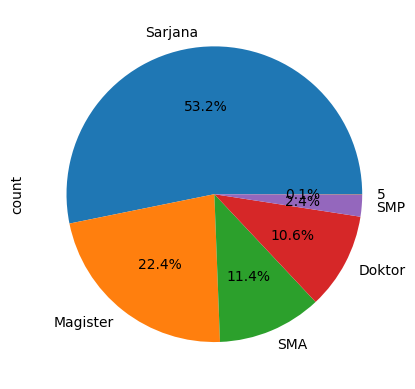

In [276]:
# Mennggunakan bantuan EDA untuk melihat data kategorik yang missing, dimana missing values bukan berarti 0, tetapi data yang salah
df['pendidikan'].value_counts().plot.pie(autopct='%1.1f%%',shadow=False)
plt.show()

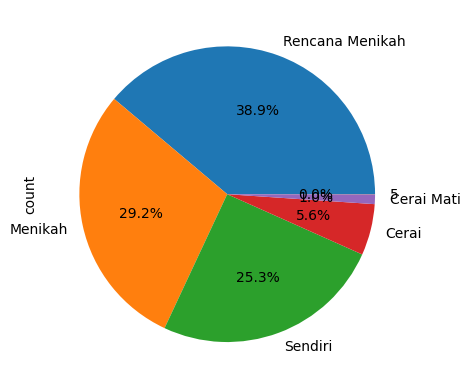

In [277]:
df['status_pernikahan'].value_counts().plot.pie(autopct='%1.1f%%',shadow=False)
plt.show()

In [278]:
df['status_pernikahan'] = df['status_pernikahan'].replace('5', df['status_pernikahan'].mode()[0])
df['pendidikan']=df['pendidikan'].replace('5', df['pendidikan'].mode()[0])

### Mengatasi Missing Values pada data yang numerik

In [279]:
# Mengatasi missing values pada data numerik menggunakan looping for
mmean = ['pendapatan','terakhir_belanja','belanja_buah','belanja_daging','belanja_ikan','belanja_kue','pembelian_diskon','pembelian_web','pembelian_toko','keluhan']

# Fill missing values with the mode
for feature in mmean:
        if feature in df.columns.values:
            df[feature] = df[feature].fillna(df[feature].mean())

### Mengatasi missing values pada data kategorik yang sudah diubah ke numerik

In [280]:
df['jumlah_anak_remaja'].fillna(0, inplace=True)

In [281]:
df['jumlah_anak_balita'].fillna(0, inplace=True)

Setelah semua data sudah fix, menambahkan variabel yang dibutuhkan

In [282]:
# Membuat kolom "Keanggotaan"
df['Keanggotaan'] = df['tanggal_menjadi_anggota'].apply(lambda x: "Anggota" if pd.notnull(x) else "Bukan Anggota")

In [283]:
# Membuat kolom baru yaitu "Total_Belanja"
df['Total_Belanja'] = df[['belanja_buah', 'belanja_daging', 'belanja_ikan', 'belanja_kue']].sum(axis=1)

In [284]:
# Menghitung total pembelian web dan pembelian toko berdasarkan status pernikahan
total_pembelian = df.groupby('status_pernikahan')[['pembelian_web', 'pembelian_toko']].sum()


In [285]:
# Menghitung ratio total belanja(currency) /pendapatan_
df['persentase_tb_pendapatan'] = df['Total_Belanja']/df['pendapatan']*100

In [286]:
#menambahkan variabel usia
#sebaran tahun kelahiran
#mengubah format
import datetime as dt
# Calculate current year
current_year = dt.datetime.now().year
df['Usia'] = current_year - df['tahun_kelahiran']

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3817 entries, 0 to 3816
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tahun_kelahiran           3817 non-null   int64  
 1   pendidikan                3817 non-null   object 
 2   status_pernikahan         3817 non-null   object 
 3   pendapatan                3817 non-null   float64
 4   jumlah_anak_balita        3817 non-null   float64
 5   jumlah_anak_remaja        3817 non-null   float64
 6   terakhir_belanja          3817 non-null   float64
 7   belanja_buah              3817 non-null   float64
 8   belanja_daging            3817 non-null   float64
 9   belanja_ikan              3817 non-null   float64
 10  belanja_kue               3817 non-null   float64
 11  pembelian_diskon          3817 non-null   float64
 12  pembelian_web             3817 non-null   float64
 13  pembelian_toko            3817 non-null   float64
 14  keluhan 

#EDA (Exploratory Data Analysis)

In [288]:
#1. Pie Chart Customer antara anggota dan bukan.

In [289]:
#3. Perbandingan karakteristik customer yang anggota dan bukan anggota berdasarkan pendapatannya.

In [290]:
#3. Perbandingan Customer yang anggota dan bukan anggota berdasarkan total belanja.

In [291]:
#4. Perbandingan karakteristik customer yang anggota maupun bukan anggota berdasarkan rata-rata rasio belanja/pendapatan

In [292]:
#5. Perbandingan karakteristik customer yang menjadi member dan belum menjadi member berdasarkan pembelian di toko dan web

In [293]:
#6. Karakteristik customer berdasarkan penggunaan diskon baik yang sudah menjadi member atau belum

#FEATURE ENGINEERING

In [294]:
#dropdata
df.drop(['tahun_kelahiran','Total_Belanja','tanggal_menjadi_anggota'],axis=1,inplace=True)

##Label Encoder

In [295]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

In [296]:
# Mengubah nilai keanggotaan
df['Keanggotaan'] = df['Keanggotaan'].map({'Anggota': 1, 'Bukan Anggota': 0})


In [297]:
# Membuat kamus untuk mapping
mapping = {'Doktor': 4, 'Magister': 3, 'Sarjana': 2, 'SMA': 1, 'SMP': 0}

# Mengganti nilai kolom 'Pendidikan' dengan nilai dari kamus mapping
df['pendidikan'] = df['pendidikan'].map(mapping)


In [298]:
category=["status_pernikahan"]
df_categorical = df[category]

In [299]:
# Ubah kedalam bentuk numerik
encoded_data = LabelEncoder()

for feature in category:
        if feature in df.columns.values:
            df[feature] = encoded_data.fit_transform(df[feature])


In [300]:
df.tail()

,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,terakhir_belanja,belanja_buah,belanja_daging,belanja_ikan,belanja_kue,pembelian_diskon,pembelian_web,pembelian_toko,keluhan,jumlah_promosi,Keanggotaan,persentase_tb_pendapatan,Usia
3812,3,2,78199470.0,0.0,0.0,33.0,6069.0,25977.0,3856.000000,5784.00000,5.0,1.0,0.0,0.0,5,0,0.053307,69
3813,4,3,109306000.0,0.0,1.0,44.0,0.0,50575.0,81428.997792,0.00000,3.0,6.0,3.0,0.0,1,1,0.120766,77
3814,3,2,104621000.0,0.0,2.0,68.0,2023.0,62713.0,8092.000000,0.00000,7.0,5.0,7.0,0.0,0,1,0.069611,50
3815,1,3,110850000.0,1.0,1.0,67.0,18207.0,70805.0,24276.000000,63377.97058,4.0,5.0,4.0,0.0,0,1,0.159374,67
3816,2,2,130512000.0,0.0,0.0,70.0,329749.0,600831.0,420784.000000,161840.00000,3.0,7.0,15.0,0.0,0,1,1.159437,63


##Scalling

In [301]:
transformation_svm = MinMaxScaler().fit(df[['pendapatan','terakhir_belanja','belanja_buah','belanja_daging', 'belanja_ikan','belanja_kue','pembelian_diskon','pembelian_web','pembelian_toko','jumlah_promosi','Usia']])
df_scaled = df.copy()
df_scaled[['pendapatan', 'terakhir_belanja', 'belanja_buah', 'belanja_daging', 'belanja_ikan', 'belanja_kue', 'pembelian_diskon', 'pembelian_web', 'pembelian_toko', 'jumlah_promosi', 'Usia']] = transformation_svm.transform(df[['pendapatan', 'terakhir_belanja', 'belanja_buah', 'belanja_daging', 'belanja_ikan', 'belanja_kue', 'pembelian_diskon', 'pembelian_web', 'pembelian_toko', 'jumlah_promosi', 'Usia']])

# Menampilkan hasil
df_scaled.head(7)

,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,terakhir_belanja,belanja_buah,belanja_daging,belanja_ikan,belanja_kue,pembelian_diskon,pembelian_web,pembelian_toko,keluhan,jumlah_promosi,Keanggotaan,persentase_tb_pendapatan,Usia
0,2,3,0.333760,0.0,1.0,0.368996,0.127551,0.074783,0.081363,0.037313,0.10,0.066667,0.294118,0.0,0.333333,1,0.333977,0.207921
1,2,3,0.240962,0.0,0.0,0.546875,0.015306,0.012754,0.130180,0.037313,0.45,0.200000,0.235294,0.0,0.000000,1,0.180490,0.495050
2,2,2,0.373568,0.0,0.0,0.351562,0.296617,0.076070,0.154989,0.268504,0.05,0.033333,0.411765,0.0,0.166667,0,0.490059,0.336634
3,3,3,0.489632,0.0,0.0,0.703125,0.520408,0.462479,0.044603,0.232159,0.00,0.233333,0.470588,0.0,0.666667,0,1.192079,0.386139
4,2,3,0.343583,1.0,1.0,0.609375,0.228401,0.089337,0.064926,0.062481,0.35,0.200000,0.294118,0.0,0.666667,0,0.404877,0.297030
5,3,4,0.272331,0.0,0.0,0.070312,0.084510,0.014107,0.000000,0.116898,0.05,0.133333,0.117647,0.0,0.833333,0,0.154871,0.475248
6,3,4,0.214270,2.0,0.0,0.750000,0.000000,0.004058,0.013018,0.003731,0.05,0.133333,0.294118,0.0,0.000000,1,0.032233,0.366337


#MODELING CLASSIFICATION

In [302]:
# Package untuk cleaning, modelling, dan evaluation model
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [303]:
X = df_scaled.drop('Keanggotaan', axis=1)
y = df_scaled['Keanggotaan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X Train : ", len(X_train))
print("y Train : ", len(y_train))
print("X Test : ", len(X_test))
print("t Test : ", len(y_test))

X Train :  3053
y Train :  3053
X Test :  764
t Test :  764


##StatModel

In [304]:
Input = sm.add_constant(X_train)

In [305]:
model = sm.Logit(y_train, X_train, missing='drop')
result = model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.461056
         Iterations 6
                             Results: Logit
Model:                 Logit              Method:             MLE        
Dependent Variable:    Keanggotaan        Pseudo R-squared:   0.221      
Date:                  2024-05-15 09:59   AIC:                2849.2070  
No. Observations:      3053               BIC:                2951.6129  
Df Model:              16                 Log-Likelihood:     -1407.6    
Df Residuals:          3036               LL-Null:            -1807.6    
Converged:             1.0000             LLR p-value:        6.3729e-160
No. Iterations:        6.0000             Scale:              1.0000     
-------------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------------
pendidikan                0.4458   0.054

In [306]:
p_values = result.pvalues
significant_params = p_values[p_values < 0.05].index
# odds ratio
round(np.exp(result.params[significant_params]), 3)

pendidikan             1.562
status_pernikahan      0.775
pendapatan             0.023
jumlah_anak_balita     2.209
jumlah_anak_remaja     1.800
belanja_daging        10.815
belanja_ikan           3.720
pembelian_web          3.217
pembelian_toko         4.045
jumlah_promosi         0.063
Usia                   0.173
dtype: float64

In [307]:
prediction = result.predict(X_test)

In [308]:
pred_results = pd.DataFrame(prediction, columns = ["logreg_pred"])
pred_results["prediksi"] = pred_results['logreg_pred'].apply(lambda x: 1 if x > 0.5 else 0)
pred_results['actual'] = y_test
pred_results.head()

,logreg_pred,prediksi,actual
2561,0.150266,0,0
1425,0.058525,0,0
2185,0.118907,0,0
2519,0.437447,0,0
3045,0.134839,0,0


In [309]:
print('Test accuracy =  {:.3f}'.format(accuracy_score(pred_results['actual'], pred_results["prediksi"])))
print('Test precision =  {:.3f}'.format(precision_score(pred_results['actual'], pred_results["prediksi"], average='macro')))
print('Test recall =  {:.3f}'.format(recall_score(pred_results['actual'], pred_results["prediksi"], average='macro')))
print('Test f-score =  {:.3f}'.format(f1_score(pred_results['actual'], pred_results["prediksi"], average='macro')))

Test accuracy =  0.780
Test precision =  0.733
Test recall =  0.676
Test f-score =  0.692


In [310]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

In [311]:
y_pred = LR.predict(X_test)
logreg_test = pd.merge(X_test, y_test, left_index=True, right_index=True, how='outer')
logreg_test['prediction'] = y_pred
logreg_test.head(5)


,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,terakhir_belanja,belanja_buah,belanja_daging,belanja_ikan,belanja_kue,pembelian_diskon,pembelian_web,pembelian_toko,keluhan,jumlah_promosi,persentase_tb_pendapatan,Usia,Keanggotaan,prediction
2561,2,3,0.343283,0.0,1.0,0.476562,0.015833,0.045597,0.007856,0.068064,0.05,0.200000,0.588235,0.0,0.500000,0.176168,0.475248,0,0
1425,2,2,0.450642,0.0,0.0,0.125000,0.598192,0.188897,0.178028,0.183872,0.00,0.333333,0.235294,0.0,0.833333,0.724305,0.336634,0,0
2185,2,4,0.106409,0.0,0.0,0.007812,0.037722,0.006471,0.028420,0.006330,0.05,0.000000,0.058824,0.0,0.500000,0.146757,0.118812,0,0
2519,2,4,0.226050,1.0,0.0,0.679688,0.030307,0.014311,0.032434,0.000000,0.05,0.166667,0.176471,0.0,0.000000,0.103716,0.267327,0,0
3045,2,2,0.442812,0.0,0.0,0.703125,0.420481,0.247914,0.172384,0.369241,0.05,0.300000,0.411765,0.0,0.666667,0.891429,0.158416,0,0


In [312]:
print('Accuracy of logistic regression classifier train data: {:.3f}'.format(LR.score(X_train, y_train)))
print('Accuracy of logistic regression classifier test data: {:.3f}'.format(LR.score(X_test, y_test)))

Accuracy of logistic regression classifier train data: 0.780
Accuracy of logistic regression classifier test data: 0.775


#CLUSTERING FOR POTENTIAL CUSTOMER

Mengacu pada hasil analisis klasifikasi sebelumnya, didapatkan bahwa variabel yang signifikan mempengaruhi customer untuk berlangganan menjadi member atau tidak pada kasus ini ialah variabel : pendidikan, status pernikahan, pendapatan, jumlah_anak_balita, jumlah_anak_remaja, pembelian_toko, jumlah_promosi

In [313]:
# Menghapus baris yang memiliki nilai keanggotaan 0
df_clust = df[df['Keanggotaan'] != 1]
df_clust=df[['pendidikan','status_pernikahan','pendapatan','jumlah_anak_balita','jumlah_anak_remaja','belanja_daging','belanja_ikan','pembelian_web','pembelian_toko','jumlah_promosi','Usia']]
df_clust.head()

,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,belanja_daging,belanja_ikan,pembelian_web,pembelian_toko,jumlah_promosi,Usia
0,2,3,1.144832e+08,0.0,1.0,260967.0,50575.0,2.0,5.0,2,45
1,2,3,8.406300e+07,0.0,0.0,44506.0,80920.0,6.0,4.0,0,74
2,2,2,1.275326e+08,0.0,0.0,265460.0,96341.0,1.0,7.0,1,58
3,3,3,1.655796e+08,0.0,0.0,1613901.0,27725.0,7.0,8.0,4,63
4,2,3,1.177032e+08,1.0,1.0,311757.0,40358.0,6.0,5.0,4,54


In [314]:
transformation_svm = MinMaxScaler().fit(df_clust[['pendapatan','belanja_daging', 'belanja_ikan','pembelian_web','pembelian_toko','jumlah_promosi','Usia']])
df_scalling = df_clust.copy()
df_scalling[['pendapatan','belanja_daging', 'belanja_ikan','pembelian_web','pembelian_toko','jumlah_promosi','Usia']]

# Menampilkan hasil
df_scaled.head(7)

,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,terakhir_belanja,belanja_buah,belanja_daging,belanja_ikan,belanja_kue,pembelian_diskon,pembelian_web,pembelian_toko,keluhan,jumlah_promosi,Keanggotaan,persentase_tb_pendapatan,Usia
0,2,3,0.333760,0.0,1.0,0.368996,0.127551,0.074783,0.081363,0.037313,0.10,0.066667,0.294118,0.0,0.333333,1,0.333977,0.207921
1,2,3,0.240962,0.0,0.0,0.546875,0.015306,0.012754,0.130180,0.037313,0.45,0.200000,0.235294,0.0,0.000000,1,0.180490,0.495050
2,2,2,0.373568,0.0,0.0,0.351562,0.296617,0.076070,0.154989,0.268504,0.05,0.033333,0.411765,0.0,0.166667,0,0.490059,0.336634
3,3,3,0.489632,0.0,0.0,0.703125,0.520408,0.462479,0.044603,0.232159,0.00,0.233333,0.470588,0.0,0.666667,0,1.192079,0.386139
4,2,3,0.343583,1.0,1.0,0.609375,0.228401,0.089337,0.064926,0.062481,0.35,0.200000,0.294118,0.0,0.666667,0,0.404877,0.297030
5,3,4,0.272331,0.0,0.0,0.070312,0.084510,0.014107,0.000000,0.116898,0.05,0.133333,0.117647,0.0,0.833333,0,0.154871,0.475248
6,3,4,0.214270,2.0,0.0,0.750000,0.000000,0.004058,0.013018,0.003731,0.05,0.133333,0.294118,0.0,0.000000,1,0.032233,0.366337


In [315]:
# Data Scaling
#scaler = StandardScaler()
#df_clust[['pendapatan','belanja_daging', 'belanja_ikan','pembelian_web','pembelian_toko','jumlah_promosi','Usia']] = scaler.fit_transform(df_clust[['pendapatan','belanja_daging', 'belanja_ikan','pembelian_web','pembelian_toko','jumlah_promosi','Usia']])
# Menampilkan hasil
#df_scalling.head(7)

In [316]:
# import package
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Package untuk visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

In [317]:
# Perulangan ini digunakan untuk mengeksekusi nilai k dengan data
# Selanjutkan akan dicari SSE

Sum_of_squared_error = []
K = range(2,10)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(df_scalling)
    Sum_of_squared_error.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

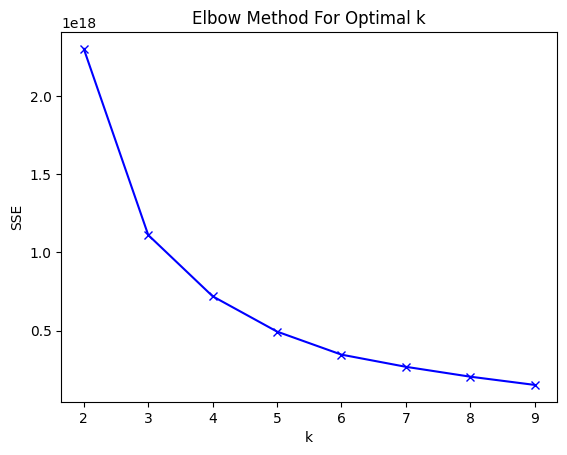

In [318]:
plt.plot(K, Sum_of_squared_error, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.show()

In [319]:
range_n_clusters = range(2,10)
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters)
    preds = clusterer.fit_predict(df_scalling)
    centers = clusterer.cluster_centers_

    score = silhouette_score(df_scalling, preds)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 2, silhouette score is 0.5687122947552842


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 3, silhouette score is 0.567635944982741


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


...

For n_clusters = 7, silhouette score is 0.5589356183615586


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 8, silhouette score is 0.5572449488737099


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 9, silhouette score is 0.5613690477015756


In [320]:
# Memodelkan data dengan k-means
cluster = KMeans(n_clusters=2)
cluster.fit(df_scalling)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=2)

In [321]:
# Membuat kolom baru berdasarkan hasil clustering
segment = pd.Series(cluster.labels_, name="segment")

In [322]:
# Menggabungkan data dengan hasil cluster
results = pd.concat([df_clust, segment], axis=1)
results.head()

,pendidikan,status_pernikahan,pendapatan,jumlah_anak_balita,jumlah_anak_remaja,belanja_daging,belanja_ikan,pembelian_web,pembelian_toko,jumlah_promosi,Usia,segment
0,2,3,1.144832e+08,0.0,1.0,260967.0,50575.0,2.0,5.0,2,45,0
1,2,3,8.406300e+07,0.0,0.0,44506.0,80920.0,6.0,4.0,0,74,1
2,2,2,1.275326e+08,0.0,0.0,265460.0,96341.0,1.0,7.0,1,58,0
3,3,3,1.655796e+08,0.0,0.0,1613901.0,27725.0,7.0,8.0,4,63,0
4,2,3,1.177032e+08,1.0,1.0,311757.0,40358.0,6.0,5.0,4,54,0


perlu diingat bahwa :<br>
Tingkat Pendidikan <br>
SMP :0 <br> SMA: 1 <br> Sarjana: 2 <br> Magister: 3 <br> Doktor: 4

Status Pernikahan :<br>
'Rencana Menikah'= <br>
'Menikah' = <br>
'Sendiri' = <br>
'Cerai' = <br>
'Cerai Mati'= <br>